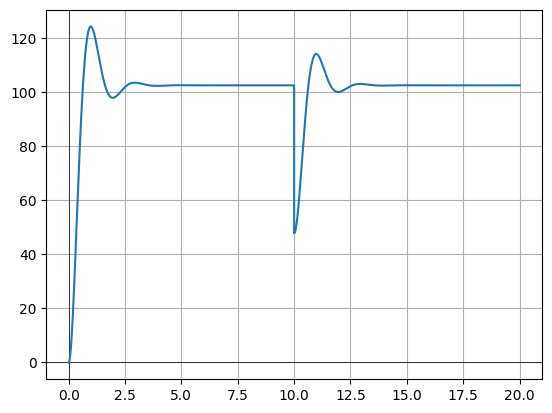

In [36]:
from scipy.integrate import odeint, solve_ivp
import numpy as np
import math
import matplotlib.pyplot as plt

#=======================
#Параметры ДПТ с постоянными магнитами
#=======================
U = 27        # напряжение, В
P2 = 2.31     # номинальная мощность, Вт
nn = 4500     # номинальная частота вращения, об/мин
Mn = 4.9e-3   # номинальный полезный момент, Нм
In = 0.28     # номинальный ток, А
Ip = 1        # пусковой ток,  Myfunc(t, x, As, Bs, M, Ung): 
L30 = 55.5e-3 # длина машины, м
L1 = 9e-3     # длина свободного конца вала, м
d30 = 25e-3   # диаметр машины, м
#=======================
Ra = U/Ip         # сопротивление обмотки якоря, Ом
wn = nn*2*math.pi/60   # номинальная угловая скорость, рад/с
La = 0.5*U/In/wn  # индуктивность обмотки якоря, Гн
Kf = (U-Ra*In)/wn # постоянная машины
M = Kf*In         # развиваемый номинальный момент на валу, Нм
M0 = M - Mn       # момент трения, Нм
L = (L30-L1)*0.4  # длина якоря, м
D = d30 * 0.8     # диаметр якоря, м
J = 800*D**4*L*0.1 # момент инерции якоря, кг*м^2
#=======================
Ka = 1/Ra
Ta = La/Ra
K1 = Ka*Kf
K2 = 1/Kf
K3 = -1/(K1*Kf)
T1 = J/(K1*Kf)
T2 = (Ta*T1)**0.5
#=======================

#=======================
#Параметры ГПТ с независимым возбуждением
#=======================
Ufg = 110 #напряжение в цепи обмотки возбуждения, В
#----------------------------------
Ung = 110     #напряжение, В
P2g = 3200    #номинальная мощность, Вт
nng = 1120    #номинальная частота вращения, об/мин
KPDg = 805   #КПД
Ra0g = 0.11   #сопротивление ОЯ, Ом
Rdg = 0.078   #сопротивление ОДП, Ом
Rf0g = 0.078  #сопротивление ОВ, Ом
Lag = 3.5e-3  #индуктивность в цепи ОЯ, Гн
L30g = 940e-3 #длина машины, м
d30g = 300e-3 #диаметр машины, м
#=======================
Rag = Ra0g + Rdg        #сопротивление в цепи обмотки якоря, Ом
Uag = Ung               #напряжение в цепи обмотки якоря, В
ifng = Ung/Rf0g         #номинальный ток в цепи ОВ, А
Rfg = Rf0g/0.65         #приведенное сопротивление ОВ, Ом
Lfg = Lag/0.06*Rfg/Rag  #индуктивность в цепи ОВ, Гн
wng = nng*2*math.pi/60       #номинальная частота вращения, рад/мин
iang = P2g*100/KPDg/Ung #номинальная ток в цепи ОЯ, А
Eang = Ung - iang*Rag   #ЭДС ОЯ в номинальном режиме
Cfg = Eang/(0.65*ifng*wng) 
lag = L30g/2            #расчетная длина якоря, м
Dag = d30g/2            #диаметр якоря, м
Jg = 800*Dag**4*lag*0.1  #момент инерции якоря, кг*м^2
Kwg = Cfg*wng
Rng = Ung/iang          #сопротивление нагрузки ГПТ
#=======================
Kfg = 1/Rfg
Tfg = Lfg/Rfg
Kag = 1/(Rag+Rng)
Tag = Lag/(Rag+Rng)
Kg = Kfg*Kwg*Kag*Rng
T1g = Tfg+ Tag
T2g = (Tfg*Tag)**0.5
#=======================
Kr = 1/300
Ku = 50
Kusil = 1

As = [
    [-Ra/La, -Kf/La, 0, 0, -Kusil*Rng/La],
    [Kf/J, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, Kr*Ku/Lfg, -Rfg/Lfg, 0],
    [0, 0, 0, Kwg/Lag, -(Rag+Rng)/Lag]
]

Bs = [
    [Kusil/La, 0, 0],
    [0, -1/J, 0],
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, -1/Lag]
]

Cs = [0, 0, 0, 0, Rng]

Ds = [0, 0, 0, 0, 0]


def Myfunc(t, x, As=As, Bs=Bs, M=M, Ung=Ung): 
    if (t < 10): dUag = 0
    else: dUag = 0.5*Ung
    u = [Ung, M, dUag]
    return np.dot(As,x) + np.dot(Bs, u)

Sol = solve_ivp(Myfunc, [0, 20], [0, 0, 0, 0, 0], method = 'RK45', rtol = 1e-9)


y = Sol.y[:][4]*Rng


plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

plt.plot(Sol.t, y)

plt.grid(True)
plt.show()